In [1]:
### load all functions and imports from AnalysisFunctions.py - make sure to update glycowork to the latest version
### note some global variables gb, glycans_in_gb, emb, glycans_in_gb_and_emb, emb_dict are defined in AnalysisFunctions.py
from AnalysisFunctions import *

In [2]:
#### Get all experimental dataset names (strings)
datasets = dir(glycomics_data_loader)
print("Number of experimental datasets: ", len(datasets))

# Loop through each dataset
for name in datasets:
    # Get the DataFrame object from the loader
    df = getattr(glycomics_data_loader, name)
    print(name)
    print(len(df.columns))
    print(df.columns)


Number of experimental datasets:  30
HIV_gagtransfection_N_PMID35112714
13
Index(['glycan', 'nontransfected_1', 'nontransfected_2', 'nontransfected_3',
       'nontransfected_4', 'mocktransfected_1', 'mocktransfected_2',
       'mocktransfected_3', 'mocktransfected_4', 'gagtransfected_1',
       'gagtransfected_2', 'gagtransfected_3', 'gagtransfected_4'],
      dtype='object')
HIV_gagtransfection_O_PMID35112714
13
Index(['glycan', 'nontransfected_1', 'nontransfected_2', 'nontransfected_3',
       'nontransfected_4', 'mocktransfected_1', 'mocktransfected_2',
       'mocktransfected_3', 'mocktransfected_4', 'gagtransfected_1',
       'gagtransfected_2', 'gagtransfected_3', 'gagtransfected_4'],
      dtype='object')
human_brain_GSL_PMID38343116
11
Index(['glycan', 'GSL_Control_1', 'GSL_Control_2', 'GSL_Control_3',
       'GSL_Control_4', 'GSL_SSSMuG_1', 'GSL_SSSMuG_2', 'GSL_SSSMuG_3',
       'GSL_SSSMuG_4', 'GSL_SSSMuG_5', 'GSL_SSSMuG_6'],
      dtype='object')
human_brain_N_PMID38343116


In [3]:
### for an exmaple dataset, access the glycan columns (df['glycan']) and the abundance data for one patient (df['SC_160320_EC_2_NG'])
df = glycomics_data_loader.human_serum_bacteremia_N_PMID33535571
print(df['glycan'])
print(df['SC_160320_EC_2_NG'])


0     Man(a1-3)[Man(a1-6)]Man(a1-6)[Man(a1-3)]Man(b1...
1     Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-...
2     Man(a1-2)Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6...
3     Man(a1-2)Man(a1-2)Man(a1-3)[Man(a1-2)Man(a1-?)...
4     Man(a1-2)Man(a1-2)Man(a1-3)[Man(a1-2)Man(a1-3)...
                            ...                        
57    {Fuc(a1-3)}Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)[N...
58    {Fuc(a1-3)}Neu5Ac(a2-3)Gal(b1-4)GlcNAc(b1-2)[N...
59    Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)[Neu5Ac(a2-?)...
60    Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)[Neu5Ac(a2-?)...
61    Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)[Neu5Ac(a2-?)...
Name: glycan, Length: 62, dtype: object
0     0.209693
1     0.925166
2     0.428598
3     0.643726
4     1.222521
        ...   
57    0.165648
58    0.386506
59    0.093673
60    0.420880
61    0.420880
Name: SC_160320_EC_2_NG, Length: 62, dtype: float64


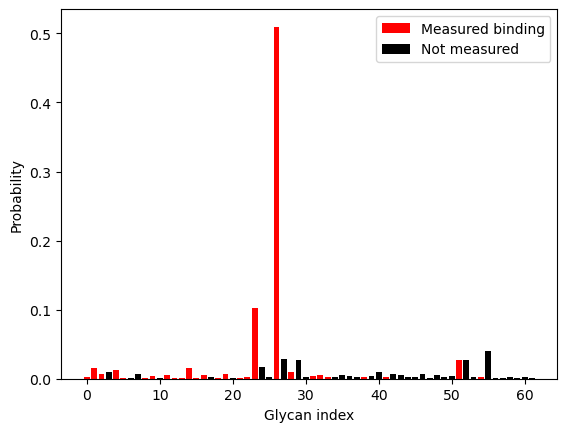

In [4]:
df = glycomics_data_loader.human_serum_bacteremia_N_PMID33535571  ## example dataset

glycans_in_df = list(df['glycan']) ## get glycans measured in the dataset

glycan_mask = [gly in gb.columns for gly in glycans_in_df] ## check if glycans are measured in the glycan binding data

groups = ['EC', 'PA', 'SA', 'SV', 'HV']  # groups corresponding to bacterial species
group_indices = get_group_indices(df, groups)  # checks 
# groupEC_list = group_indices['EC']
# groupPA_list = group_indices['PA']
# groupSA_list = group_indices['SA']
# groupSV_list = group_indices['SV']
# groupHV_list = group_indices['HV']
# print(groupEC_list)

g = group_indices[groups[3]][0] # get one of the group's measurements of glycans
glycan_dist = prob_dist(np.array(df[g]))  ## convert to probability by normalization

plt.figure()
plt.bar([i for i in range(len(glycan_dist)) if glycan_mask[i]], [glycan_dist[i] for i in range(len(glycan_dist)) if glycan_mask[i]], color='red', alpha=1, label='Measured binding') # False is blue
plt.bar([i for i in range(len(glycan_dist)) if not glycan_mask[i]], [glycan_dist[i] for i in range(len(glycan_dist)) if not glycan_mask[i]], color='black', alpha=1, label='Not measured') # False is blue
plt.ylabel('Probability')
plt.xlabel('Glycan index')
plt.legend()


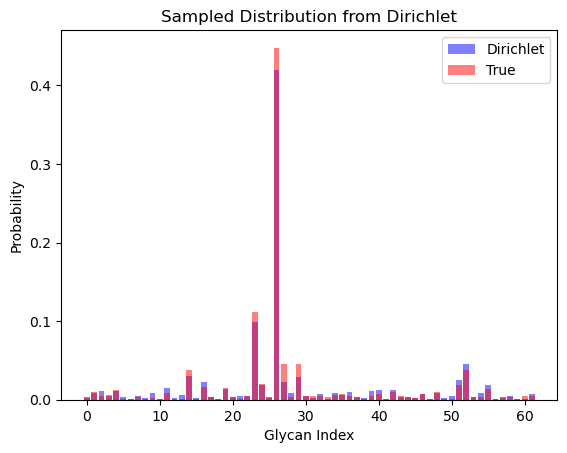

In [5]:
## fit a different Dirichlet distribution for each group, alphas are the parameters of the Dirichlet distribution
group_alphas = fit_dirichlet_distribution_mle(df, group_indices)  

## visualize for one group sample
true = prob_dist(np.array(df[group_indices['EC'][0]])) 
samp = dirichlet.rvs(group_alphas['EC'], size = 1)[0] # sample once from the fit for this group 

plt.figure()
plt.bar(np.array(range(len(samp))), samp, color = 'blue', alpha = 0.5, label = 'Dirichlet')
plt.bar(np.array(range(len(true))), true, color = 'red', alpha = 0.5, label = 'True')
plt.xlabel('Glycan Index')
plt.ylabel('Probability')
plt.title('Sampled Distribution from Dirichlet')
plt.legend()



1148    Gal_8-short
373           Gal_1
Name: protein, dtype: object
0.14347127253860087


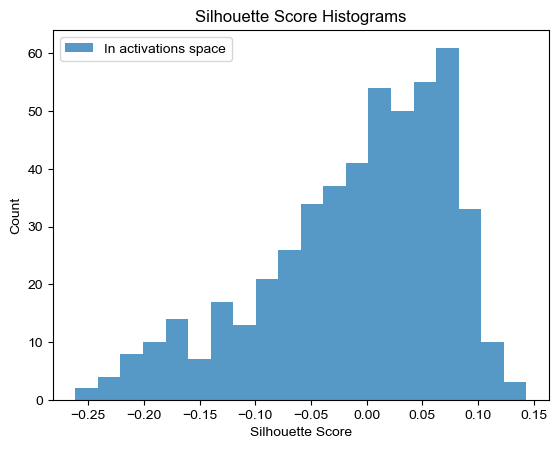

In [35]:
## here we sample groups of proteins and compute the silhouette score of the activation space to find the group with the best separation
## this cell takes a minute or so to run depending on n_samples

ss_act_list = []
ss_dist_list = []
ss_act_z_list = []
max_ss_act = -float('inf')
max_ss_act_z = -float('inf')
prot_names_with_scores = []  # List of (score, names) tuples

n_lectins = 2  ## how many lectins to project onto 
n_samples = 500  ## how many times to sample proteins
for _ in range(n_samples):
    try:
        ss_act, ss_dist, prot_names = sample_proteins_and_get_silhouette_score(n_lectins, glycans_in_df, emb, group_indices, df)
    except:
        continue
    prot_names_with_scores.append((ss_act, prot_names))
    ss_act_list.append(ss_act)
    ss_dist_list.append(ss_dist)

# Sort by score in descending order
max_ss_act = max([prot_names_with_scores[m][0] for m in range(len(prot_names_with_scores))])
max_ind = [prot_names_with_scores[m][0] for m in range(len(prot_names_with_scores))].index(max_ss_act)
max_ss_act_prot_names = prot_names_with_scores[max_ind][1]

print(max_ss_act_prot_names)
print(max_ss_act)
plt.hist(ss_act_list, bins=20, alpha=0.75, label='In activations space')

plt.xlabel('Silhouette Score')
plt.ylabel('Count')
plt.title('Silhouette Score Histograms')
plt.legend()
plt.show()


['Gal_8-short', 'Gal_1']


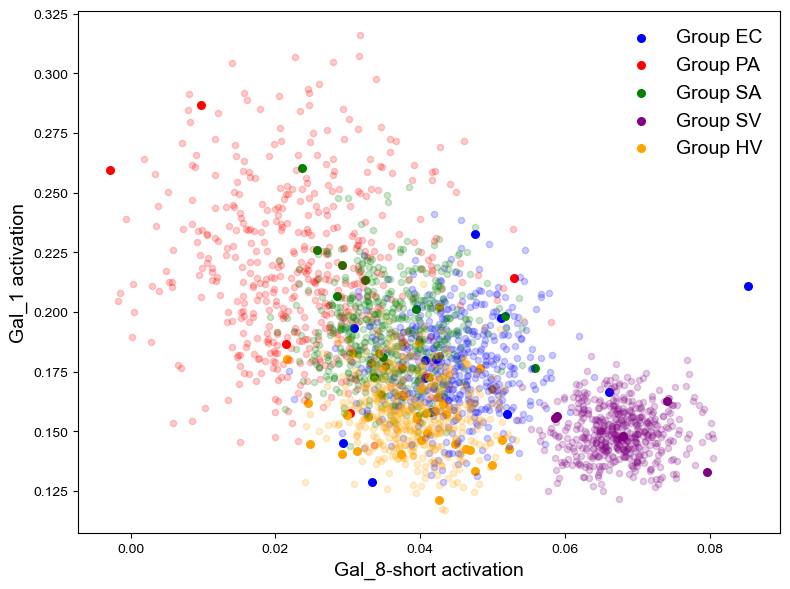

In [37]:
# Combined visualization code for 1D, 2D, and 3D projections
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde

## either set the lectins by hand or use the highest scoring lectins
prot_1 = "ConA"
prot_2 = "WGA"
prot_names = [prot_1, prot_2]

prot_names = [max_ss_act_prot_names.iloc[i] for i in range(len(max_ss_act_prot_names))]

print(prot_names)
prot_seq_list = build_prot_seq_list(prot_names)

# Switch between dimensions (1, 2, or 3)
dimension = len(prot_names)  # Change this to 1, 2, or 3

# Set up the plot based on dimension
if dimension == 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.rcParams['font.family'] = 'Arial'
elif dimension == 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.rcParams['font.family'] = 'Arial'
else:  # dimension == 3
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    plt.rcParams['font.family'] = 'Arial'

# Colors for groups
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']

# Plot main activation arrays
data_alpha = 1
data_size = 30
for i, (group, activation_array) in enumerate(activation_arrays.items()):
    if dimension == 1:
        ax.scatter(activation_array[0,:], [0]*len(activation_array[0,:]), 
                   color=colors[i], label=f'Group {group}', alpha=data_alpha, s=data_size)
    elif dimension == 2:
        ax.scatter(activation_array[0,:], activation_array[1,:], 
                   color=colors[i], label=f'Group {group}', alpha=data_alpha, s=data_size)
    else:  # 3D
        ax.scatter(activation_array[0,:], activation_array[1,:], activation_array[2,:], 
                   color=colors[i], label=f'Group {group}', alpha=data_alpha, s=data_size)

# Plot sampled activation arrays (with lower alpha)
sample_alpha = 0.2
sample_size = 20
for i, (group, activation_array) in enumerate(activation_arrays_sample.items()):
    if dimension == 1:
        ax.scatter(activation_array[0,:], [0]*len(activation_array[0,:]),
                   color=colors[i], alpha=sample_alpha, s=sample_size)
        ax.hist(activation_array[0,:], bins=30, color=colors[i], 
                alpha=0.3, density=True)
    elif dimension == 2:
        ax.scatter(activation_array[0,:], activation_array[1,:],
                   color=colors[i], alpha=sample_alpha, s=sample_size)
    else:  # 3D
        ax.scatter(activation_array[0,:], activation_array[1,:], activation_array[2,:],
                   color=colors[i], alpha=sample_alpha, s=sample_size)

# Set labels and legend
fs = 14
pad = 20

if dimension == 1:
    ax.set_xlabel(f'{prot_names[0]} activation', fontsize=fs)
    ax.set_ylabel('', fontsize=fs)
    ax.set_yticks([])
elif dimension == 2:
    ax.set_xlabel(f'{prot_names[0]} activation', fontsize=fs)
    ax.set_ylabel(f'{prot_names[1]} activation', fontsize=fs)
else:  # 3D
    ax.set_xlabel(f'{prot_names[0]} activation', fontsize=fs, labelpad=pad)
    ax.set_ylabel(f'{prot_names[1]} activation', fontsize=fs, labelpad=pad)
    ax.set_zlabel(f'{prot_names[2]} activation', fontsize=fs, labelpad=pad)
    ax.view_init(elev=15, azim=285)


ax.legend(fontsize=fs,frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
### optionally export things to do classification on later
# #filepath = '/Users/csfloyd/Dropbox/Projects/MarkovComputation/GlycanData/Bacteria' + '_' + prot_names[0] + '_' + prot_names[1] + '.pkl'
# filepath = '/Users/csfloyd/Dropbox/Projects/MarkovComputation/GlycanData/Bacteria' + '_' + prot_names[0] + '.pkl'
# export_data_for_sampling(z_score_mat, group_indices, df, filepath)
